In [3]:
! pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [28]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.info()

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!unrar x "/content/drive/My Drive/output_photos_rus_signes.rar" "/content/drive/My Drive/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/My Drive/output_photos_rus_signes.rar

Extracting  /content/drive/My Drive/output_photos_rus_signes/data.yaml       0%  OK 
Creating    /content/drive/My Drive/output_photos_rus_signes/images   OK
Creating    /content/drive/My Drive/output_photos_rus_signes/images/test  OK
Extracting  /content/drive/My Drive/output_photos_rus_signes/images/test/autosave01_02_2012_09_17_27.jpg       0%  OK 
Extracting  /content/drive/My Drive/output_photos_rus_signes/images/test/autosave09_10_2012_11_02_41_1.jpg       0%  OK 
Extracting  /content/drive/My Drive/output_photos_rus_signes/images/test/autosave09_10_2012_11_02_55_1.jpg       0%  OK 
Extracting  /content/drive/My Drive/output_photos_rus_signes/images/test/autosave09_10_2012_11_03_07_2.jpg       0%  OK 
Extracting  /content/drive/My Drive/output_photos_rus_signes/images/test/autosave09_10_2012_

In [7]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [8]:
!find /content -maxdepth 4 -type d | grep output_photos


/content/drive/MyDrive/output_photos_rus_signes
/content/drive/.Encrypted/MyDrive/output_photos_rus_signes


In [ ]:
import yaml

with open("/content/output_photos_rus_signes/data.yaml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

data


{'path': '/content/output_photos_rus_signes',
 'train': 'images/train',
 'val': 'images/val',
 'test': 'images/test',
 'nc': 6,
 'names': ['warning',
  'priority',
  'prohibitory',
  'mandatory',
  'information',
  'service']}

СТАТИСТИКА ПО ДАТАСЕТУ

--- TRAIN сплит ---
Изображений с аннотациями: 585
Пустых изображений (без знаков): 4
Всего объектов: 1183

Распределение по классам:

--- VAL сплит ---
Изображений с аннотациями: 73
Пустых изображений (без знаков): 1
Всего объектов: 138

Распределение по классам:

--- TEST сплит ---
Изображений с аннотациями: 73
Пустых изображений (без знаков): 1
Всего объектов: 125

Распределение по классам:


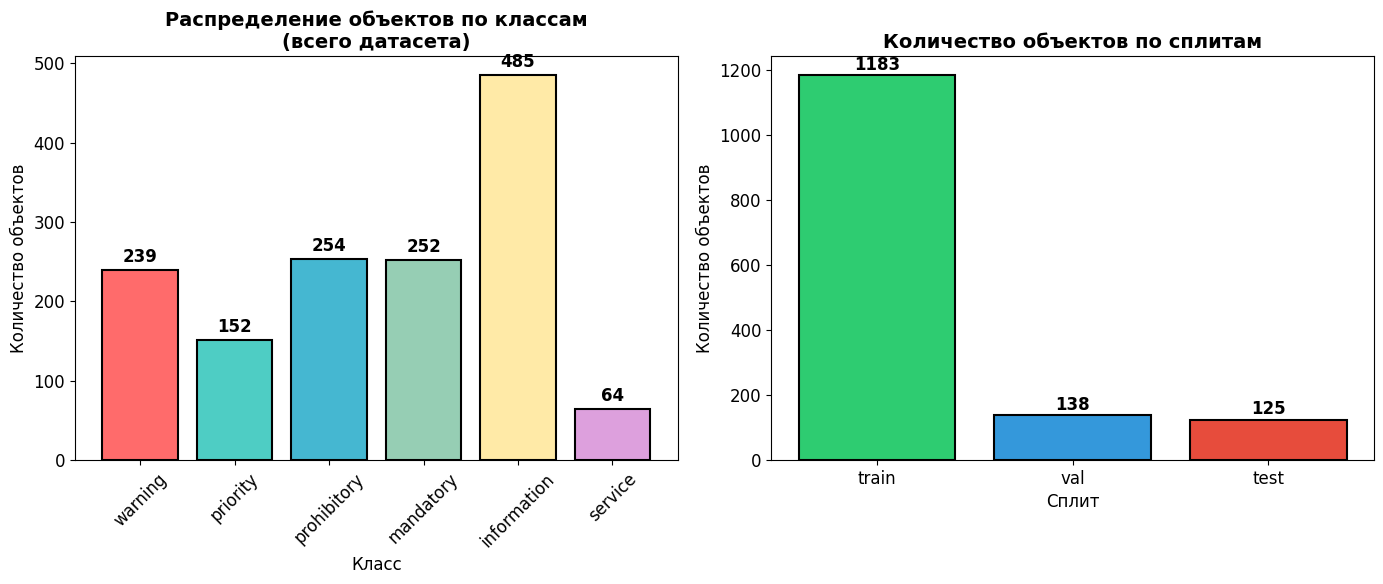

In [19]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def count_objects_in_yolo_dataset(labels_dir, num_classes=6):
    """
    Подсчитывает количество объектов по классам в YOLO-датасете
    """
    class_counts = {i: 0 for i in range(num_classes)}
    total_files = 0
    empty_files = 0

    txt_files = list(Path(labels_dir).glob('*.txt'))
    total_files = len(txt_files)

    for txt_file in txt_files:
        with open(txt_file, 'r') as f:
            lines = f.readlines()

            if len(lines) == 0:
                empty_files += 1
                continue

            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = int(parts[0])
                    if class_id < num_classes:
                        class_counts[class_id] += 1

    return class_counts, total_files, empty_files


datasets = {
    'train': '/content/drive/My Drive/output_photos_rus_signes/labels/train',
    'val': '/content/drive/My Drive/output_photos_rus_signes/labels/val',
    'test': '/content/drive/My Drive/output_photos_rus_signes/labels/test'
}

class_names = {
    0: 'warning (предупреждающие)',
    1: 'priority (знаки приоритета)',
    2: 'prohibitory (запрещающие)',
    3: 'mandatory (предписывающие)',
    4: 'information (информационные)',
    5: 'service (сервиса)'
}

total_counts = {i: 0 for i in range(6)}
total_images_all = 0
total_empty_all = 0
total_objects_all = 0

print("=" * 60)
print("СТАТИСТИКА ПО ДАТАСЕТУ")
print("=" * 60)

split_data = {}

for split_name, labels_path in datasets.items():
    if not os.path.exists(labels_path):
        print(f"Путь не найден: {labels_path}")
        continue

    counts, total_imgs, empty_imgs = count_objects_in_yolo_dataset(labels_path, 6)
    total_objects = sum(counts.values())

    split_data[split_name] = {
        'counts': counts,
        'total_imgs': total_imgs,
        'empty_imgs': empty_imgs,
        'total_objects': total_objects
    }

    for class_id, count in counts.items():
        total_counts[class_id] += count
    total_images_all += total_imgs
    total_empty_all += empty_imgs
    total_objects_all += total_objects

    print(f"\n--- {split_name.upper()} сплит ---")
    print(f"Изображений с аннотациями: {total_imgs}")
    print(f"Пустых изображений (без знаков): {empty_imgs}")
    print(f"Всего объектов: {total_objects}")
    print("\nРаспределение по классам:")



plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

classes_short = ['warning', 'priority', 'prohibitory', 'mandatory', 'information', 'service']
counts_list = [total_counts[i] for i in range(6)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

bars = axes[0].bar(classes_short, counts_list, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Распределение объектов по классам\n(всего датасета)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Класс', fontsize=12)
axes[0].set_ylabel('Количество объектов', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars, counts_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontweight='bold')

split_names = list(split_data.keys())
split_counts = [split_data[split]['total_objects'] for split in split_names]

colors_splits = ['#2ECC71', '#3498DB', '#E74C3C']
bars2 = axes[1].bar(split_names, split_counts, color=colors_splits, edgecolor='black', linewidth=1.5)
axes[1].set_title('Количество объектов по сплитам', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Сплит', fontsize=12)
axes[1].set_ylabel('Количество объектов', fontsize=12)

for bar, count in zip(bars2, split_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



In [10]:
cd

/root


In [21]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def analyze_bbox_sizes(labels_dir, images_dir=None, img_size=1024):
    """
    Анализирует размеры bounding boxes в YOLO-датасете
    Автоматически определяет все классы
    """
    bbox_widths = []
    bbox_heights = []
    bbox_areas = []
    aspect_ratios = []

    class_areas = defaultdict(list)
    all_class_ids = set()

    txt_files = list(Path(labels_dir).glob('*.txt'))

    for txt_file in txt_files:
        with open(txt_file, 'r') as f:
            lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    all_class_ids.add(class_id)

                    # Нормализованные координаты (0-1)
                    cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

                    # Переводим в пиксели
                    width_px = w * img_size
                    height_px = h * img_size
                    area = width_px * height_px
                    aspect = width_px / height_px if height_px > 0 else 0

                    bbox_widths.append(width_px)
                    bbox_heights.append(height_px)
                    bbox_areas.append(area)
                    aspect_ratios.append(aspect)
                    class_areas[class_id].append(area)

    return {
        'widths': bbox_widths,
        'heights': bbox_heights,
        'areas': bbox_areas,
        'aspect_ratios': aspect_ratios,
        'class_areas': dict(class_areas),
        'all_class_ids': sorted(all_class_ids),
        'total_bboxes': len(bbox_widths)
    }

labels_dir = '/content/drive/My Drive/output_photos_rus_signes/labels/train'

stats = analyze_bbox_sizes(labels_dir, img_size=1024)

print(f"Всего bbox проанализировано: {stats['total_bboxes']}")
print(f"Средняя ширина: {np.mean(stats['widths']):.1f} px")
print(f"Средняя высота: {np.mean(stats['heights']):.1f} px")
print(f"Средняя площадь: {np.mean(stats['areas']):.1f} px²")
print(f"Медианная площадь: {np.median(stats['areas']):.1f} px²")

small = sum(1 for a in stats['areas'] if a < 32*32)
medium = sum(1 for a in stats['areas'] if 32*32 <= a < 96*96)
large = sum(1 for a in stats['areas'] if a >= 96*96)

print(f"\nРаспределение по размерам (при imgsz=1024):")
print(f"  Мелкие (<32x32): {small} ({small/stats['total_bboxes']*100:.1f}%)")
print(f"  Средние (32-96px): {medium} ({medium/stats['total_bboxes']*100:.1f}%)")
print(f"  Крупные (>96px): {large} ({large/stats['total_bboxes']*100:.1f}%)")

Найденные классы: [0, 1, 2, 3, 4, 5, 6]
Всего bbox проанализировано: 1184
Средняя ширина: 50.5 px
Средняя высота: 79.2 px
Средняя площадь: 4714.2 px²
Медианная площадь: 3134.6 px²

Распределение по размерам (при imgsz=1024):
  Мелкие (<32x32): 149 (12.6%)
  Средние (32-96px): 892 (75.3%)
  Крупные (>96px): 143 (12.1%)


/tmp/ipykernel_2755/1409471954.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
/tmp/ipykernel_2755/1409471954.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()


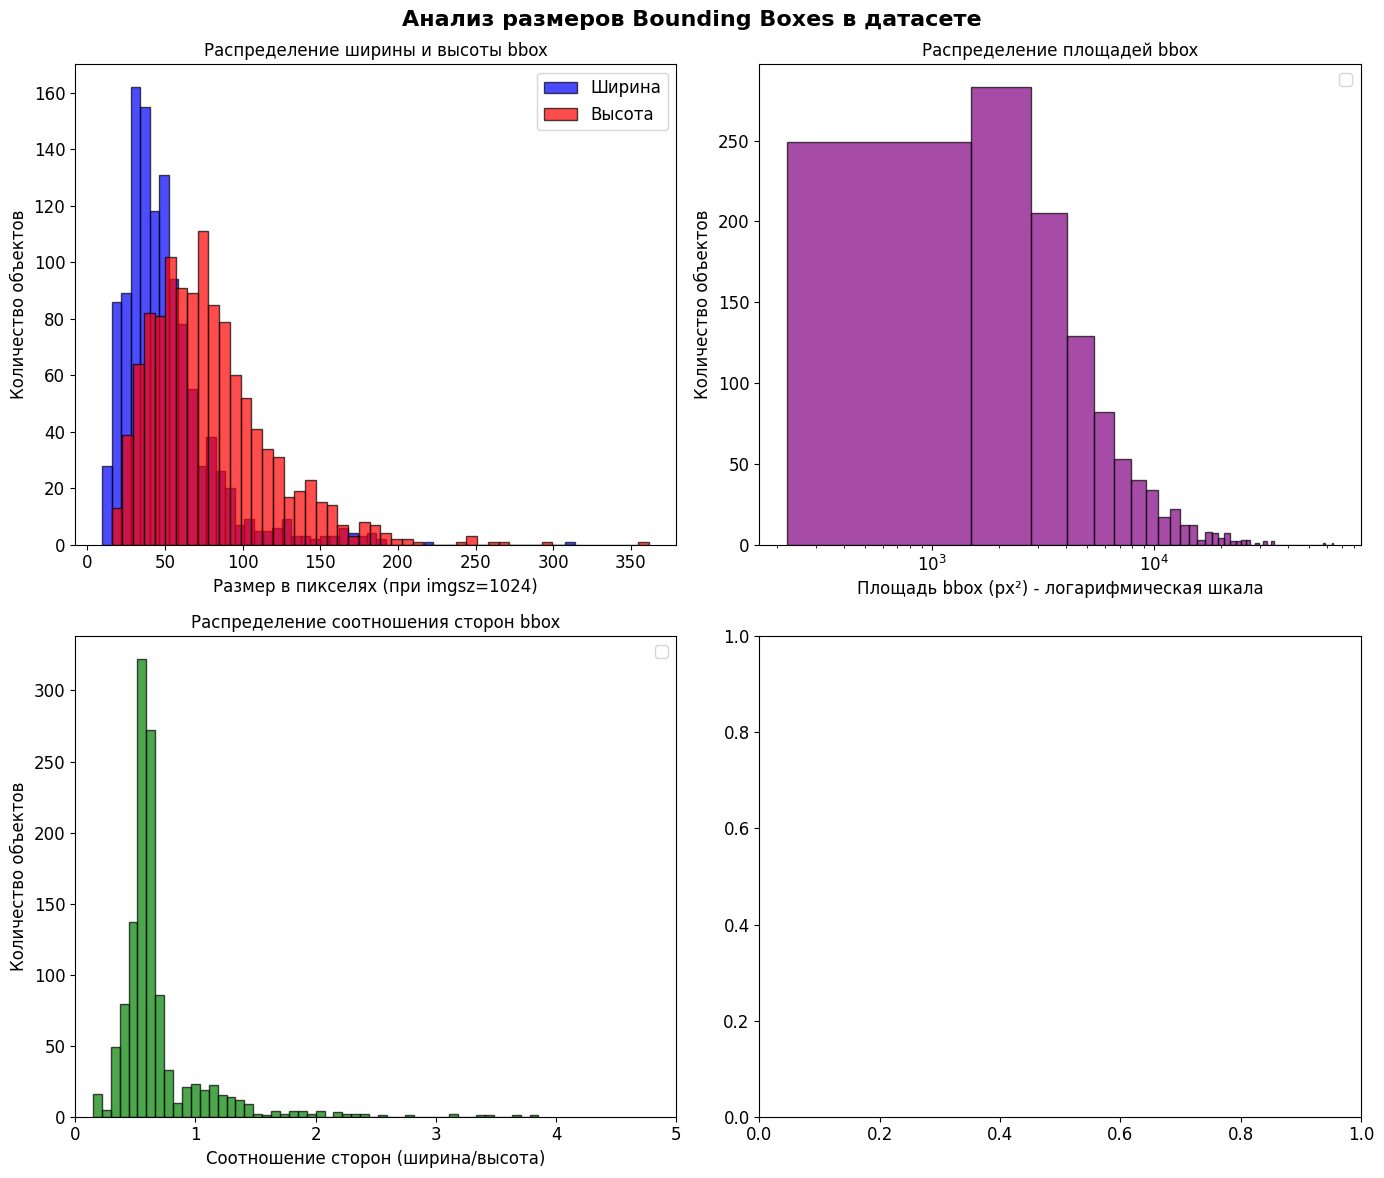

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Анализ размеров Bounding Boxes в датасете', fontsize=16, fontweight='bold')

axes[0,0].hist(stats['widths'], bins=50, alpha=0.7, label='Ширина', color='blue', edgecolor='black')
axes[0,0].hist(stats['heights'], bins=50, alpha=0.7, label='Высота', color='red', edgecolor='black')
axes[0,0].set_xlabel('Размер в пикселях (при imgsz=1024)', fontsize=12)
axes[0,0].set_ylabel('Количество объектов', fontsize=12)
axes[0,0].set_title('Распределение ширины и высоты bbox', fontsize=12)
axes[0,0].legend()
axes[0,0].legend()

axes[0,1].hist(stats['areas'], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0,1].set_xscale('log')
axes[0,1].set_xlabel('Площадь bbox (px²) - логарифмическая шкала', fontsize=12)
axes[0,1].set_ylabel('Количество объектов', fontsize=12)
axes[0,1].set_title('Распределение площадей bbox', fontsize=12)
axes[0,1].legend()

axes[1,0].hist(stats['aspect_ratios'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1,0].set_xlabel('Соотношение сторон (ширина/высота)', fontsize=12)
axes[1,0].set_ylabel('Количество объектов', fontsize=12)
axes[1,0].set_title('Распределение соотношения сторон bbox', fontsize=12)
axes[1,0].legend()
axes[1,0].set_xlim(0, 5)


plt.tight_layout()
plt.show()

In [34]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/drive/My Drive/output_photos_rus_signes/data.yaml",
    epochs=100,
    imgsz=1024,
    batch=16,
    device=0,
    project="/content/runs2",
    name="rus_signs_1024",
    pretrained=True,
    patience=20,
    seed=42,
    fliplr=0.0,
    warmup_epochs=3,
    cos_lr=True
)


Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/My Drive/output_photos_rus_signes/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rus_signs_1024-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [45]:

model = YOLO("/content/runs2/rus_signs_1024-5/weights/best.pt")

metrics = model.val(
    data="/content/drive/My Drive/output_photos_rus_signes/data.yaml",
    split="test",
    conf=0.25,
    iou=0.5,
    plots=True,
    save_json=True
)

print("✅ Confusion matrix сохранена в папке runs/")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 45.0±16.5 MB/s, size: 86.4 KB)
val: Scanning /content/drive/My Drive/output_photos_rus_signes/labels/test.cache... 73 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 17.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.5s
                   all         73        125      0.907      0.885      0.863      0.622
               warning         24         24          1      0.833      0.835      0.549
              priority         12         12      0.917      0.917      0.915      0.687
           prohibitory         17         21      0.818      0.857      0.815      0.565
             mandatory         15         20      0.864       0.95      0.917      0.691
           information 

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

model = YOLO("/content/runs2/rus_signs_1024-5/weights/best.pt")

# Получаем предсказания на test
results = model.val(data="/content/drive/My Drive/output_photos_rus_signes/data.yaml",
                    split="test",
                    conf=0.25,
                    save_txt=False,
                    save_json=True)

# Строим матрицу ошибок
def plot_confusion_matrix(model, data_yaml, class_names):
    # Загружаем результаты валидации
    val_results = model.val(data=data_yaml, split="test", plots=False)

    # Получаем confusion matrix из результатов
    # (Ultralytics сохраняет ее в папку, но можно построить свою)

    # Альтернатива: использовать встроенный метод
    model.val(data=data_yaml, split="test", plots=True)

    print("✅ Confusion matrix сохранена")

class_names = ['warning', 'priority', 'prohibitory', 'mandatory', 'information', 'service']
plot_confusion_matrix(model, "/content/drive/My Drive/output_photos_rus_signes/data.yaml", class_names)

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 62.7±7.3 MB/s, size: 114.9 KB)
val: Scanning /content/drive/My Drive/output_photos_rus_signes/labels/test.cache... 73 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 21.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5s/it 7.3s
                   all         73        125        0.9      0.885      0.863      0.626
               warning         24         24      0.952      0.833      0.833      0.572
              priority         12         12      0.917      0.917      0.915      0.687
           prohibitory         17         21      0.818      0.857      0.815      0.565
             mandatory         15         20      0.864       0.95      0.917      0.691
           information 

In [49]:
import pandas as pd

model = YOLO("/content/runs2/rus_signs_1024-5/weights/best.pt")

metrics = model.val(
    data="/content/drive/My Drive/output_photos_rus_signes/data.yaml",
    split="test",
    conf=0.25,
    iou=0.5,
    verbose=True
)

print("ОБЩИЕ МЕТРИКИ НА TEST-СПЛИТЕ")
print(f"mAP50 (IoU=0.5): {metrics.box.map50:.4f}")
print(f"mAP50-95 (IoU=0.5:0.95): {metrics.box.map:.4f}")
print(f"Precision (средняя): {metrics.box.p.mean():.4f}")
print(f"Recall (средний): {metrics.box.r.mean():.4f}")


print("МЕТРИКИ ПО КАЖДОМУ КЛАССУ")

class_names = ['warning', 'priority', 'prohibitory', 'mandatory', 'information', 'service']

metrics_df = pd.DataFrame({
    'Класс': class_names,
    'Precision': metrics.box.p,
    'Recall': metrics.box.r,
    'mAP50': metrics.box.ap50,
    'mAP50-95': metrics.box.ap
})

print(metrics_df.to_string(index=False))

metrics_df.to_csv('/content/drive/My Drive/test_metrics.csv', index=False)

print("ДЕТАЛЬНЫЕ МЕТРИКИ (по каждому классу)")
for i, name in enumerate(class_names):
    print(f"\n{name}:")
    print(f"  Precision: {metrics.box.p[i]:.4f}")
    print(f"  Recall: {metrics.box.r[i]:.4f}")
    print(f"  mAP50: {metrics.box.ap50[i]:.4f}")
    print(f"  mAP50-95: {metrics.box.ap[i]:.4f}")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 47.6±10.1 MB/s, size: 86.9 KB)
val: Scanning /content/drive/My Drive/output_photos_rus_signes/labels/test.cache... 73 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 17.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.7s
                   all         73        125      0.907      0.885      0.863      0.622
               warning         24         24          1      0.833      0.835      0.549
              priority         12         12      0.917      0.917      0.915      0.687
           prohibitory         17         21      0.818      0.857      0.815      0.565
             mandatory         15         20      0.864       0.95      0.917      0.691
           information 

In [39]:
cd

/root


In [40]:
ls


output_photos_rus_signes/  runs/  yolo11n.pt  yolo26n.pt


In [41]:
cd ..

/


In [42]:
ls

bin@                        lib32@                    root/
boot/                       lib64@                    run/
content/                    libx32@                   sbin@
cuda-keyring_1.1-1_all.deb  media/                    srv/
datalab/                    mnt/                      sys/
dev/                        NGC-DL-CONTAINER-LICENSE  tmp/
etc/                        opt/                      tools/
home/                       proc/                     usr/
kaggle/                     python-apt/               var/
lib@                        python-apt.tar.xz*


In [43]:
cd content

/content


In [44]:
ls

drive/  runs2/  sample_data/  yolo11n.pt


In [51]:
import time
import torch
from ultralytics import YOLO

def benchmark_fps(model_path, imgsz=640, batch_size=1, num_warmup=50, num_iterations=200):
    """
    Измеряет FPS модели на GPU
    """
    model = YOLO(model_path)

    dummy_input = torch.randn(batch_size, 3, imgsz, imgsz).cuda()

    print(f"Прогрев GPU ({num_warmup} итераций)...")
    for _ in range(num_warmup):
        _ = model.predict(dummy_input, verbose=False)

    torch.cuda.synchronize()
    start_time = time.time()

    for _ in range(num_iterations):
        _ = model.predict(dummy_input, verbose=False)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    fps = num_iterations * batch_size / total_time

    print("БЕНЧМАРК FPS")
    print(f"Модель: {model_path}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Размер входного изображения: {imgsz}x{imgsz}")
    print(f"Batch size: {batch_size}")
    print(f"Всего итераций: {num_iterations}")
    print(f"Общее время: {total_time:.2f} сек")
    print(f"FPS: {fps:.2f}")

    return fps


print("ИЗМЕРЕНИЕ FPS НА T4")


fps_640 = benchmark_fps(
    model_path="/content/runs2/rus_signs_1024-5/weights/best.pt",
    imgsz=640,
    batch_size=1,
    num_warmup=30,
    num_iterations=100
)

fps_1024 = benchmark_fps(
    model_path="/content/runs2/rus_signs_1024-5/weights/best.pt",
    imgsz=1024,
    batch_size=1,
    num_warmup=30,
    num_iterations=100
)

fps_batch = benchmark_fps(
    model_path="/content/runs2/rus_signs_1024-5/weights/best.pt",
    imgsz=640,
    batch_size=16,
    num_warmup=20,
    num_iterations=50
)

print("СРАВНЕНИЕ FPS")

print(f"imgsz=640, batch=1: {fps_640:.2f} FPS")
print(f"imgsz=1024, batch=1: {fps_1024:.2f} FPS")
print(f"imgsz=640, batch=16: {fps_batch:.2f} FPS")


ИЗМЕРЕНИЕ FPS НА T4
Прогрев GPU (30 итераций)...
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.105050563812256. Dividing input by 255

In [ ]:
from ultralytics import YOLO
import cv2
from tqdm import tqdm
import os

# Загружаем обученную модель
model = YOLO("/content/runs2/rus_signs_1024-5/weights/best.pt")


input_video_path = "/content/drive/My Drive/test_video.mp4"
output_video_path = "/content/drive/My Drive/detected_video_demo.mp4"



def process_video(input_path, output_path, conf_threshold=0.4, imgsz=640):

    # Открываем видео
    cap = cv2.VideoCapture(input_path)

    # Получаем параметры видео
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Видео: {total_frames} кадров, {fps} FPS, {width}x{height}")

    # Настройка кодека для сохранения
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    # Цвета для классов
    colors = {
        0: (0, 0, 255),     # warning - красный
        1: (0, 255, 0),     # priority - зеленый
        2: (255, 0, 0),     # prohibitory - синий
        3: (0, 255, 255),   # mandatory - желтый
        4: (255, 0, 255),   # information - пурпурный
        5: (255, 255, 0)    # service - голубой
    }

    class_names = {
        0: 'warning',
        1: 'priority',
        2: 'prohibitory',
        3: 'mandatory',
        4: 'information',
        5: 'service'
    }

    # Обрабатываем кадры
    frame_count = 0
    processed_frames = 0

    # Выбираем каждый 2-й кадр для ускорения (опционально)
    frame_step = 1

    with tqdm(total=total_frames, desc="Обработка видео") as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_count += 1
            if frame_count % frame_step != 0:
                out.write(frame)
                pbar.update(1)
                continue

            # Детекция на кадре
            results = model(frame, conf=conf_threshold, imgsz=imgsz, verbose=False)

            # Рисуем bounding boxes
            for r in results:
                boxes = r.boxes
                if boxes is not None:
                    for box in boxes:
                        # Координаты
                        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                        conf = float(box.conf[0])
                        cls = int(box.cls[0])

                        # Рисуем прямоугольник
                        color = colors.get(cls, (255, 255, 255))
                        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

                        # Добавляем подпись
                        label = f"{class_names[cls]}: {conf:.2f}"
                        label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]

                        # Рисуем фон для текста
                        cv2.rectangle(frame, (x1, y1 - label_size[1] - 5),
                                    (x1 + label_size[0], y1), color, -1)
                        # Рисуем текст
                        cv2.putText(frame, label, (x1, y1 - 5),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

            # Добавляем информационную панель
            info_text = f"Detections: {len(boxes) if boxes else 0} | Conf: {conf_threshold}"
            cv2.putText(frame, info_text, (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

            # Записываем кадр
            out.write(frame)
            processed_frames += 1
            pbar.update(1)

    # Закрываем все
    cap.release()
    out.release()
    cv2.destroyAllWindows()

    print(f"\n✅ Видео сохранено: {output_path}")
    print(f"   Обработано кадров: {processed_frames}")

    return output_path

# Проверяем, существует ли видео
input_video = "/content/drive/My Drive/test_video.mp4"

if not os.path.exists(input_video):
    print("Видео не найдено. Скачиваем пример...")
    input_video = download_example_video()

# Обрабатываем видео
output_video = process_video(
    input_path=input_video,
    output_path="/content/drive/My Drive/detected_demo.mp4",
    conf_threshold=0.4,  # используем оптимальный порог
    imgsz=640  # можно 640 или 1024
)

print(f"\n🎬 Готово! Видео сохранено: {output_video}")

Видео: 46369 кадров, 29 FPS, 1280x720


Обработка видео:  55%|█████▍    | 25344/46369 [09:25<07:45, 45.19it/s]